# Lab 17: Review preprocessing and sentiment analysis

Uses 40 authored, labeled example reviews, not customer records. Lowercasing/character cleaning, training-only TF-IDF and logistic regression. Small synthetic demonstration; score does not estimate real-world sentiment performance.

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
Path('figures').mkdir(exist_ok=True)


Example-data test accuracy: 0.3333333333333333
              precision    recall  f1-score   support

    negative       0.25      0.17      0.20         6
    positive       0.38      0.50      0.43         6

    accuracy                           0.33        12
   macro avg       0.31      0.33      0.31        12
weighted avg       0.31      0.33      0.31        12

                         Review                         Cleaned
great product excellent quality great product excellent quality
       love this useful product        love this useful product
   amazing service very helpful    amazing service very helpful
excellent value works perfectly excellent value works perfectly
fast delivery wonderful quality fast delivery wonderful quality
                             Review Prediction
excellent quality and great service   positive
 terrible quality and slow delivery   negative


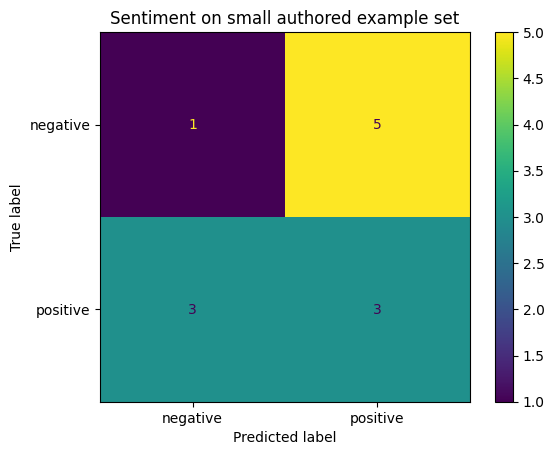

In [2]:
import pandas as pd,re
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,ConfusionMatrixDisplay
positive=['great product excellent quality','love this useful product','amazing service very helpful','excellent value works perfectly','fast delivery wonderful quality','fantastic purchase highly recommend','good design very comfortable','happy with this excellent purchase','reliable item works great','wonderful experience helpful staff','great quality and good price','perfect fit love the design','easy to use fantastic results','excellent support friendly service','very satisfied good performance','amazing quality highly recommended','great value fast shipping','love it wonderful product','helpful service perfect delivery','good purchase reliable quality']
negative=['bad product poor quality','hate this useless product','terrible service very rude','poor value broken item','slow delivery awful quality','disappointing purchase not recommended','bad design very uncomfortable','unhappy with this terrible purchase','unreliable item fails badly','awful experience rude staff','poor quality and high price','wrong fit hate the design','hard to use disappointing results','terrible support unfriendly service','very dissatisfied bad performance','awful quality not recommended','bad value slow shipping','hate it terrible product','rude service failed delivery','bad purchase unreliable quality']
df=pd.DataFrame({'Review':positive+negative,'Sentiment':['positive']*len(positive)+['negative']*len(negative)})
def clean(text):return re.sub(r'[^a-z\s]',' ',text.lower()).strip()
df['Cleaned']=df['Review'].map(clean);df.to_csv('example_reviews.csv',index=False)
X_train,X_test,y_train,y_test=train_test_split(df['Cleaned'],df['Sentiment'],test_size=.3,random_state=42,stratify=df['Sentiment'])
model=make_pipeline(TfidfVectorizer(ngram_range=(1,2)),LogisticRegression(random_state=42));model.fit(X_train,y_train);pred=model.predict(X_test)
print('Example-data test accuracy:',accuracy_score(y_test,pred));print(classification_report(y_test,pred,zero_division=0));print(df[['Review','Cleaned']].head().to_string(index=False))
new=['excellent quality and great service','terrible quality and slow delivery'];print(pd.DataFrame({'Review':new,'Prediction':model.predict([clean(t) for t in new])}).to_string(index=False))
ConfusionMatrixDisplay.from_predictions(y_test,pred);plt.title('Sentiment on small authored example set');plt.show()
